<!-- open-in-badges -->
[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/02_deep_training/notebooks/sesion_02_4_residual_diagnosticos.ipynb) [![Abrir en Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/02_deep_training/notebooks/sesion_02_4_residual_diagnosticos.ipynb) [![Abrir en Lightning Studio](https://pl-bolts-doc-images.s3.us-east-2.amazonaws.com/app-2/studio-badge.svg)](https://lightning.ai/new?repo_url=https%3A%2F%2Fgithub.com%2FEAFIT-IA%2Fsi7011-DeepLearning%2Fblob%2Fmain%2Fsessions%2F02_deep_training%2Fnotebooks%2Fsesion_02_4_residual_diagnosticos.ipynb)

# SI7011 · Sesión 02 · 4. Conexiones residuales y diagnósticos
**Juan David Martínez Vargas · Universidad EAFIT**

Acompaña la **Parte 5** de las diapositivas. La teoría está allá; aquí cada celda cambia **una sola cosa** y comparamos curvas.

| Sección | Lo que cambia | Qué mirar |
|---|---|---|
| 1 | profundidad 4, 20 y 50 sin residuales | más capas, peor **entrenamiento** |
| 2 | bloque residual $x + F(x)$ | 50 capas que sí entrenan |
| 3 | el gradiente de la primera capa | el camino directo hacia atrás |
| 4 | LayerNorm dentro del bloque (*pre-norm*) | estabilidad con $\eta$ alto |
| 5 | pérdida inicial y sobreajustar un lote | diagnósticos antes de entrenar |
| 6 | un error clásico | cómo lo detecta el diagnóstico |

Corre en CPU en 1–2 minutos (Colab, Kaggle, Lightning o local).

In [1]:
import copy, math, time
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import torch
from torch import nn
from torchvision import datasets

torch.manual_seed(0)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
int_epochs = lambda: plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
print('PyTorch', torch.__version__)

PyTorch 2.14.1+cu130


## Datos: Fashion-MNIST como vectores
Son los mismos datos en los cuatro notebooks de la sesión. Cada imagen de 28×28 se aplana en un vector de 784 valores. Se usan 10 000 ejemplos de entrenamiento, 10 000 de validación (tomados del resto del conjunto de entrenamiento) y el conjunto de prueba oficial. El escalado se calcula **solo** con entrenamiento.

In [2]:
train_set = datasets.FashionMNIST('data', train=True, download=True)
test_set = datasets.FashionMNIST('data', train=False, download=True)
CLASSES = train_set.classes

X = train_set.data.reshape(-1, 784).float() / 255
y = train_set.targets
perm = torch.randperm(len(X), generator=torch.Generator().manual_seed(0))
X_train, y_train = X[perm[:10_000]], y[perm[:10_000]]
X_val, y_val = X[perm[50_000:]], y[perm[50_000:]]
X_test, y_test = test_set.data.reshape(-1, 784).float() / 255, test_set.targets

mu, sd = X_train.mean(), X_train.std()          # estadísticas solo de entrenamiento
X_train, X_val, X_test = [(t - mu) / sd for t in (X_train, X_val, X_test)]
X_train.shape, X_val.shape, X_test.shape

(torch.Size([10000, 784]), torch.Size([10000, 784]), torch.Size([10000, 784]))

## Herramientas: entrenar, evaluar y graficar
Es el mismo loop de la sesión 01 y se define una sola vez. Lo que cambia en cada sección es el **modelo** o el **optimizador**.

In [3]:
loss_fn = nn.CrossEntropyLoss()

def train_epoch(model, opt, batch_size=128):
    model.train()
    perm = torch.randperm(len(X_train))
    total = 0.0
    for i in range(0, len(X_train), batch_size):
        b = perm[i:i + batch_size]
        loss = loss_fn(model(X_train[b]), y_train[b])
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * len(b)
    return total / len(X_train)

@torch.no_grad()
def evaluate(model, X, y):
    model.eval()
    logits = model(X)
    return loss_fn(logits, y).item(), (logits.argmax(1) == y).float().mean().item()

In [4]:
def fit(model, opt, epochs=10, batch_size=128):
    hist = {'loss': [], 'val_loss': [], 'val_acc': []}
    t0 = time.time()
    for epoch in range(epochs):
        hist['loss'].append(train_epoch(model, opt, batch_size))
        val_loss, val_acc = evaluate(model, X_val, y_val)
        hist['val_loss'].append(val_loss); hist['val_acc'].append(val_acc)
    print(f"época {epochs}: loss {hist['loss'][-1]:.3f} · val_loss {val_loss:.3f} · val_acc {val_acc:.3f} · {time.time() - t0:.1f} s")
    return hist

def plot_curves(hists, key='loss', title='', logy=False):
    for name, h in hists.items():
        plt.plot(range(1, len(h[key]) + 1), h[key], label=name)
    if logy: plt.yscale('log')
    plt.xlabel('época'); plt.ylabel(key); plt.title(title); plt.legend(); int_epochs(); plt.show()

## 1. ¿Más profundo es mejor?
Son MLP planos con ReLU, inicialización He (notebook 1) y Adam. **Cambia un número:** la profundidad.

In [5]:
def plain_mlp(depth, width=128, he=True):
    layers, n_in = [], 784
    for _ in range(depth):
        layers += [nn.Linear(n_in, width), nn.ReLU()]
        n_in = width
    model = nn.Sequential(*layers, nn.Linear(width, 10))
    for m in model:
        if he and isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu'); nn.init.zeros_(m.bias)
    return model

In [6]:
h_plain = {}
for depth in [4, 20, 50]:
    torch.manual_seed(0)
    model = plain_mlp(depth)
    h_plain[depth] = fit(model, torch.optim.Adam(model.parameters(), lr=1e-3), epochs=8)

época 8: loss 0.278 · val_loss 0.416 · val_acc 0.857 · 1.3 s


época 8: loss 0.387 · val_loss 0.486 · val_acc 0.836 · 3.9 s


época 8: loss 0.969 · val_loss 0.873 · val_acc 0.663 · 8.8 s


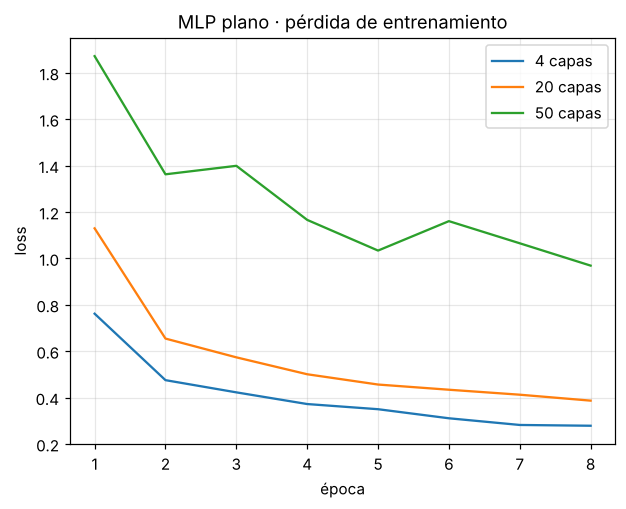

In [7]:
plot_curves({f'{d} capas': h for d, h in h_plain.items()}, title='MLP plano · pérdida de entrenamiento')

El modelo de 50 capas tiene más capacidad que el de 4 y, aun así, su pérdida de **entrenamiento** es mucho peor. Esto no es sobreajuste, porque el sobreajuste se ve en validación. Es un problema de **optimización**: la red más profunda podría imitar a la de 4 capas (bastaría con que las capas sobrantes fueran la identidad), pero el optimizador no encuentra esa solución. Es la degradación de la diapositiva *Deeper is not automatically better*.

## 2. El bloque residual
Si aprender la identidad es difícil, la ponemos gratis: el bloque calcula $x + F(x)$ y solo tiene que aprender la **corrección** $F$. Con $F=0$, el bloque ya es la identidad.

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(width, width), nn.ReLU(), nn.Linear(width, width))

    def forward(self, x):
        return x + self.f(x)            # el atajo: x pasa sin cambios

def residual_mlp(blocks, width=128):
    return nn.Sequential(nn.Linear(784, width),
                         *[ResidualBlock(width) for _ in range(blocks)],
                         nn.ReLU(), nn.Linear(width, 10))

n_linear = lambda m: sum(isinstance(l, nn.Linear) for l in m.modules())
n_linear(plain_mlp(50)), n_linear(residual_mlp(25))

(51, 52)

Las dos redes tienen prácticamente el mismo número de capas `Linear` (51 y 52). **Cambia la arquitectura:** las 50 capas ocultas se agrupan en 25 bloques con atajo. No usamos He: dejamos la inicialización por defecto de PyTorch.

In [9]:
torch.manual_seed(0)
model = residual_mlp(25)
h_res = fit(model, torch.optim.Adam(model.parameters(), lr=1e-3), epochs=8)

época 8: loss 0.331 · val_loss 0.410 · val_acc 0.855 · 9.0 s


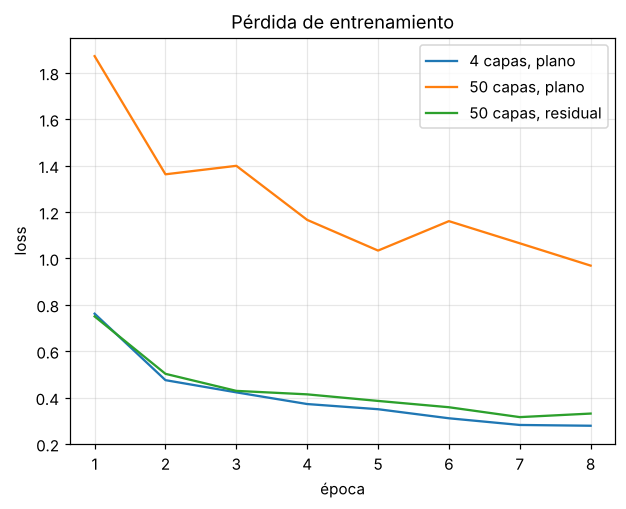

In [10]:
plot_curves({'4 capas, plano': h_plain[4], '50 capas, plano': h_plain[50], '50 capas, residual': h_res}, title='Pérdida de entrenamiento')

Con atajos, la red de 50 capas entrena casi tan bien como la de 4. La profundidad dejó de ser un obstáculo.

## 3. Un camino directo para el gradiente
¿Por qué funciona? Como $\partial(x + F(x))/\partial x = I + \partial F/\partial x$, el gradiente tiene un término que atraviesa cada bloque **sin multiplicarse** por los pesos. Lo medimos con la inicialización por defecto en las dos redes:

In [11]:
def first_layer_grad(model):
    model.zero_grad()
    loss_fn(model(X_train[:512]), y_train[:512]).backward()
    return next(m for m in model.modules() if isinstance(m, nn.Linear)).weight.grad.norm().item()

torch.manual_seed(0); plain_default = plain_mlp(50, he=False)
torch.manual_seed(0); res_default = residual_mlp(25)
print(f'50 capas planas    ‖∇W₁‖ = {first_layer_grad(plain_default):.1e}')
print(f'25 bloques residual ‖∇W₁‖ = {first_layer_grad(res_default):.1e}')

50 capas planas    ‖∇W₁‖ = 7.1e-20
25 bloques residual ‖∇W₁‖ = 3.7e+00


Sin atajos, el gradiente que llega a la primera capa es del orden de $10^{-20}$, que en la práctica es cero. Con atajos llega intacto. Por eso, con residuales, la inicialización deja de ser crítica.

## 4. LayerNorm dentro del bloque
Los atajos suman: después de muchos bloques, la escala de $x$ puede crecer, sobre todo con un $\eta$ alto. La solución estándar es normalizar **la entrada de $F$**: $x + F(\operatorname{LN}(x))$. Es el bloque *pre-norm* de los Transformers (sesión 05). Como LayerNorm normaliza cada ejemplo, no depende del lote (notebook 3).

**Cambia una línea del bloque** y subimos $\eta$ a $10^{-2}$.

In [12]:
class PreNormBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.f = nn.Sequential(nn.LayerNorm(width), nn.Linear(width, width), nn.ReLU(), nn.Linear(width, width))   # NUEVO: LayerNorm

    def forward(self, x):
        return x + self.f(x)

def prenorm_mlp(blocks, width=128):
    return nn.Sequential(nn.Linear(784, width),
                         *[PreNormBlock(width) for _ in range(blocks)],
                         nn.ReLU(), nn.Linear(width, 10))

In [13]:
torch.manual_seed(0)
model = residual_mlp(25)
h_res_hi = fit(model, torch.optim.Adam(model.parameters(), lr=1e-2), epochs=8)

torch.manual_seed(0)
model = prenorm_mlp(25)
h_ln_hi = fit(model, torch.optim.Adam(model.parameters(), lr=1e-2), epochs=8)

época 8: loss 0.462 · val_loss 0.502 · val_acc 0.823 · 8.3 s


época 8: loss 0.336 · val_loss 0.447 · val_acc 0.846 · 10.3 s


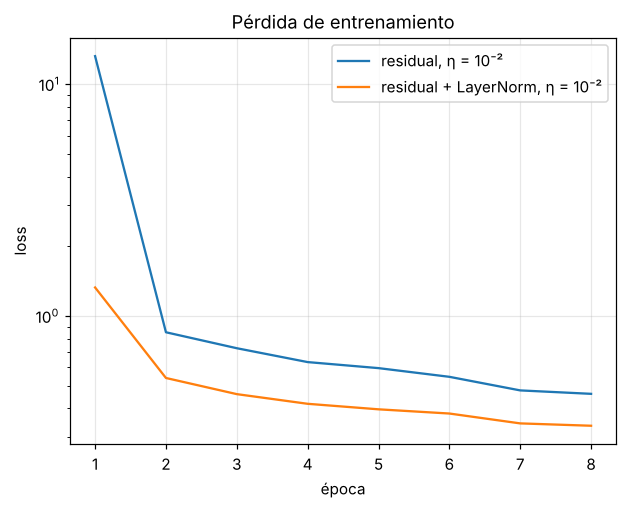

In [14]:
plot_curves({'residual, η = 10⁻²': h_res_hi, 'residual + LayerNorm, η = 10⁻²': h_ln_hi}, title='Pérdida de entrenamiento', logy=True)

Sin LayerNorm, la primera época con $\eta=10^{-2}$ arranca con una pérdida enorme (la escala se disparó) y la red queda peor durante todo el entrenamiento. Con *pre-norm*, el mismo $\eta$ es seguro. En el notebook 3, LayerNorm no lograba rescatar un MLP plano; dentro de un bloque residual es justamente la pieza que le faltaba.

## 5. Diagnósticos antes de entrenar
Son dos verificaciones baratas que conviene correr **siempre**, antes de gastar tiempo en entrenar:

1. **Pérdida inicial** $\approx \ln C$ (notebook 1, sección 7).
2. **Sobreajustar un lote**: con 64 ejemplos y unos cientos de pasos, un modelo correcto debe llevar la pérdida casi a **cero**. Si no lo logra, hay un error en el modelo, en la pérdida o en el loop, y entrenar más no lo va a arreglar.

In [15]:
def overfit_one_batch(model, n=64, steps=300):
    xb, yb = X_train[:n], y_train[:n]
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for _ in range(steps):
        loss = loss_fn(model(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()
    return loss.item()

torch.manual_seed(0)
model = residual_mlp(10)
with torch.no_grad():
    print(f'pérdida inicial: {loss_fn(model(X_train[:512]), y_train[:512]).item():.3f}   (ln 10 = {math.log(10):.3f})')
print(f'pérdida tras sobreajustar 64 ejemplos: {overfit_one_batch(model):.4f}')

pérdida inicial: 2.365   (ln 10 = 2.303)


pérdida tras sobreajustar 64 ejemplos: 0.0000


## 6. Un error clásico
`nn.CrossEntropyLoss` espera **logits** y aplica `log_softmax` por dentro. Un error frecuente es poner un `nn.Softmax` al final del modelo, "porque queremos probabilidades". El código corre sin errores y la pérdida baja… un poco. **Cambia una línea:** agregamos `nn.Softmax(dim=1)` a la salida.

In [16]:
torch.manual_seed(0)
buggy = nn.Sequential(residual_mlp(10), nn.Softmax(dim=1))      # el error
with torch.no_grad():
    print(f'pérdida inicial: {loss_fn(buggy(X_train[:512]), y_train[:512]).item():.3f}')
print(f'pérdida tras sobreajustar 64 ejemplos: {overfit_one_batch(buggy):.4f}')

pérdida inicial: 2.302


pérdida tras sobreajustar 64 ejemplos: 1.4612


La pérdida inicial sale bien, así que esa verificación **no lo detecta**. Sobreajustar un lote sí: la pérdida se queda trabada lejos de cero. Con softmax doble, la salida está acotada en $[0,1]$ antes del `log_softmax`, así que la probabilidad máxima que el modelo puede asignar es $e/(e+9)\approx 0.23$. El mínimo alcanzable es $-\ln 0.23 \approx 1.46$, justo donde se trabó.

In [17]:
-math.log(math.e / (math.e + 9))

1.4611501717344748

## Mapa de diagnóstico
Es un resumen de la diapositiva *Training diagnostics map*, con el notebook donde se vio cada caso.

| Síntoma | Qué medir | Qué cambiar | Notebook |
|---|---|---|---|
| la pérdida queda en $\ln C$ | std de activaciones, $\lVert\nabla_{W_1}J\rVert$ | He, BatchNorm, residuales | 1, 3, 4 |
| pérdida inicial absurda | escala de los logits | inicialización, capa de salida | 1 |
| `nan` en las primeras épocas | norma del gradiente | bajar $\eta$, clipping, warmup | 2 |
| baja muy lento | curva de entrenamiento | subir $\eta$, momentum, Adam | 2 |
| más capas, peor **entrenamiento** | pérdida de entrenamiento | conexiones residuales | 4 |
| entrenamiento ↓, validación ↑ | brecha entre las dos curvas | Dropout, weight decay, early stopping, más datos | 3 |
| no sobreajusta ni un lote | sobreajustar 64 ejemplos | buscar el error en modelo, pérdida o loop | 4 |

## Tu turno · 10 minutos
1. Repite la sección 1 con 100 capas planas y con 50 bloques residuales. ¿Hasta dónde aguanta cada uno?
2. Quita el atajo (`return self.f(x)`) en `ResidualBlock` y repite la sección 3. ¿Qué gradiente obtienes?
3. Pon LayerNorm **después** de la suma: `return self.norm(x + self.f(x))` (*post-norm*). Compáralo con *pre-norm* a $\eta=10^{-2}$.
4. Inventa otro error y comprueba si el diagnóstico lo detecta. Algunas ideas: olvidar `opt.zero_grad()`, pasar `y` desordenado o usar `lr=0`.
5. Corre `overfit_one_batch` sobre `plain_mlp(50)`. ¿Lo logra? ¿Qué te dice eso sobre la sección 1?

**Para pensar.** El MLP plano de 50 capas tiene gradientes sanos con He (notebook 1) y aun así entrena peor que la versión residual. ¿Qué le falta, si el gradiente llega bien?

In [18]:
# Experimento 1: 100 capas planas frente a 50 bloques residuales


### Referencias
- He, Zhang, Ren y Sun (2016), *Deep Residual Learning for Image Recognition*, CVPR, e *Identity Mappings in Deep Residual Networks*, ECCV.
- Ba, Kiros y Hinton (2016), *Layer Normalization* · Xiong et al. (2020), *On Layer Normalization in the Transformer Architecture*, ICML (pre-norm frente a post-norm).
- Karpathy (2019), [*A Recipe for Training Neural Networks*](https://karpathy.github.io/2019/04/25/recipe/) (sobreajustar un lote, verificar la pérdida inicial).